All libraries imported successfully!
Please upload the file: train_u6lujuX_CVtuZ9i.csv


Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i (1).csv
Dataset loaded successfully!
(614, 13)

DATASET OVERVIEW

Shape: 614 rows × 13 columns

Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows:

MISSING VALUES BEFORE CLEANING
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


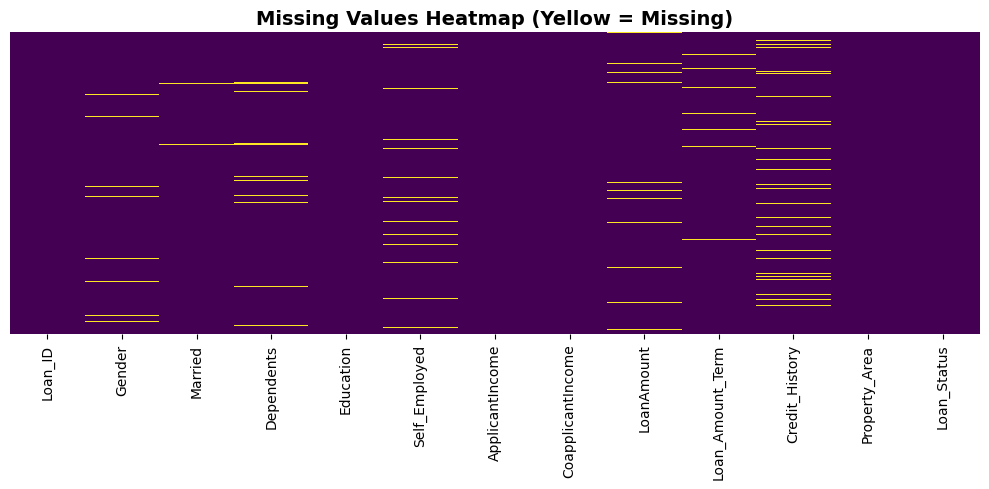


MISSING VALUES AFTER CLEANING:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

 All missing values handled!

EXPLORATORY DATA ANALYSIS


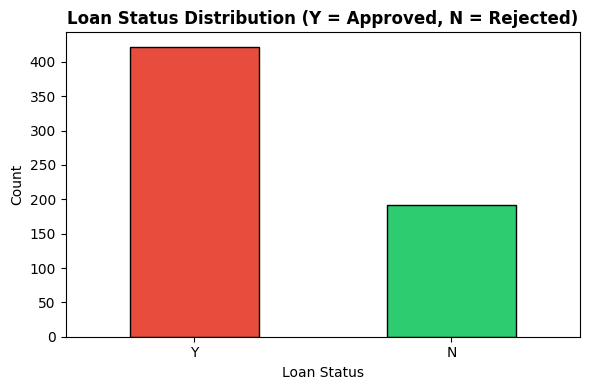

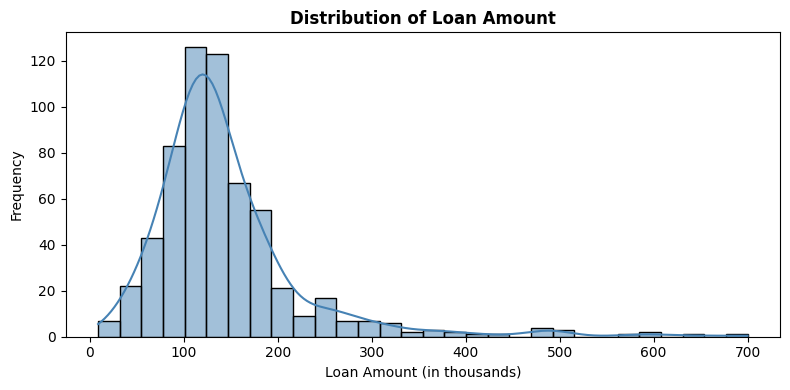

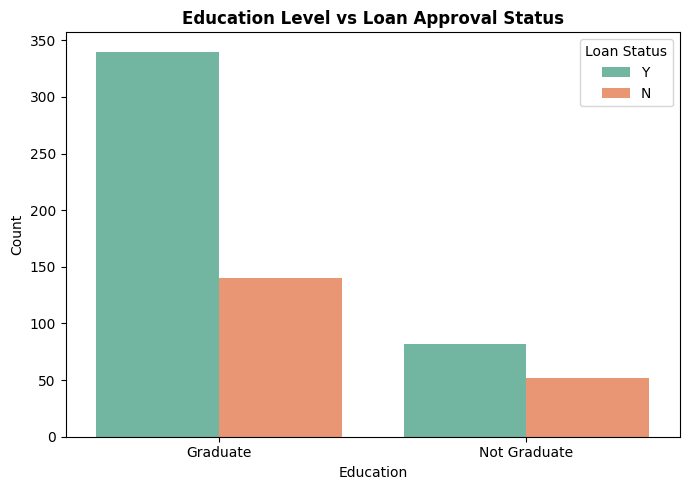

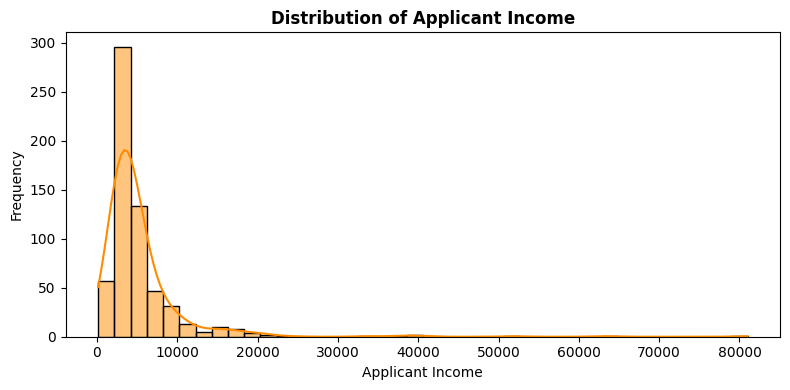

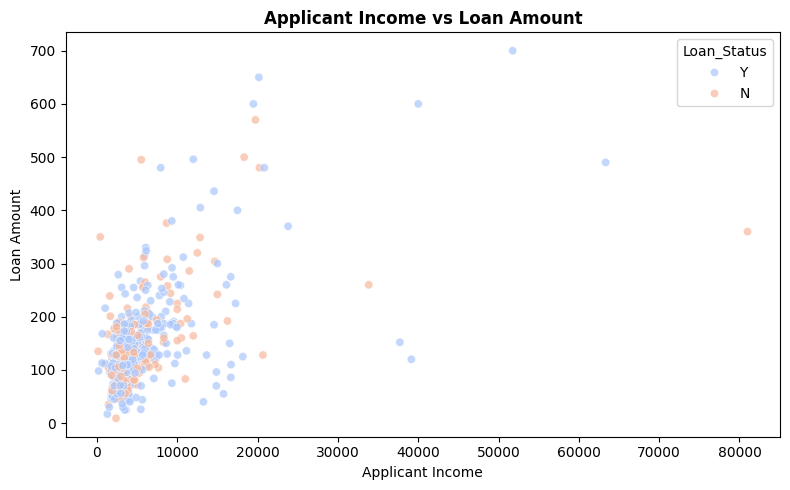

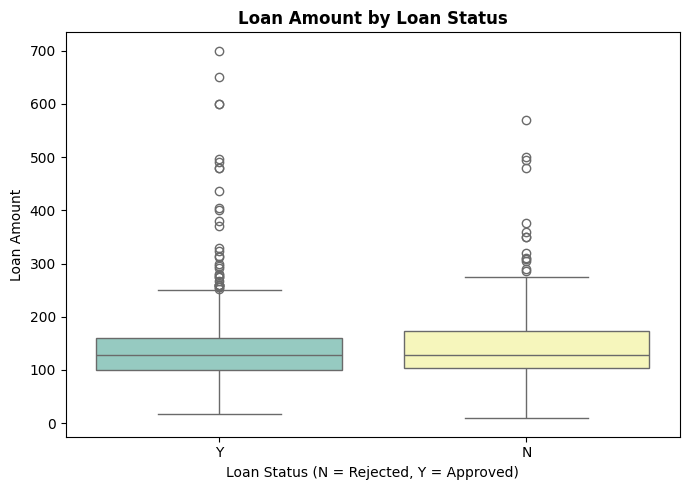

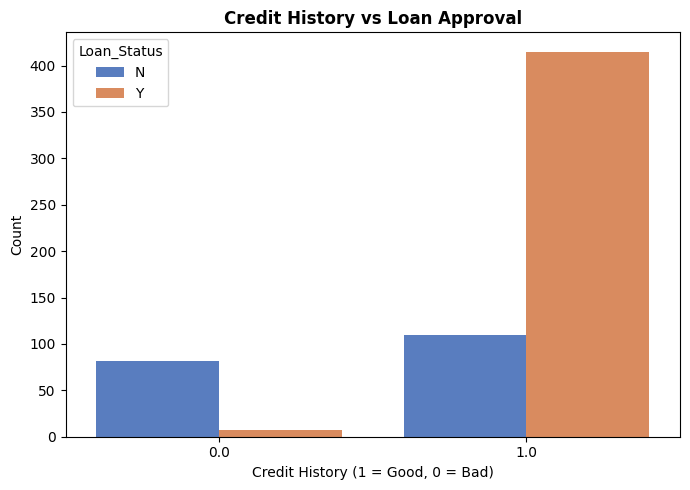


ENCODING CATEGORICAL FEATURES
  Encoded: Gender
  Encoded: Married
  Encoded: Dependents
  Encoded: Education
  Encoded: Self_Employed
  Encoded: Property_Area
  Encoded: Loan_Status

 Encoding complete!

Final Dataset Shape: (614, 12)
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0

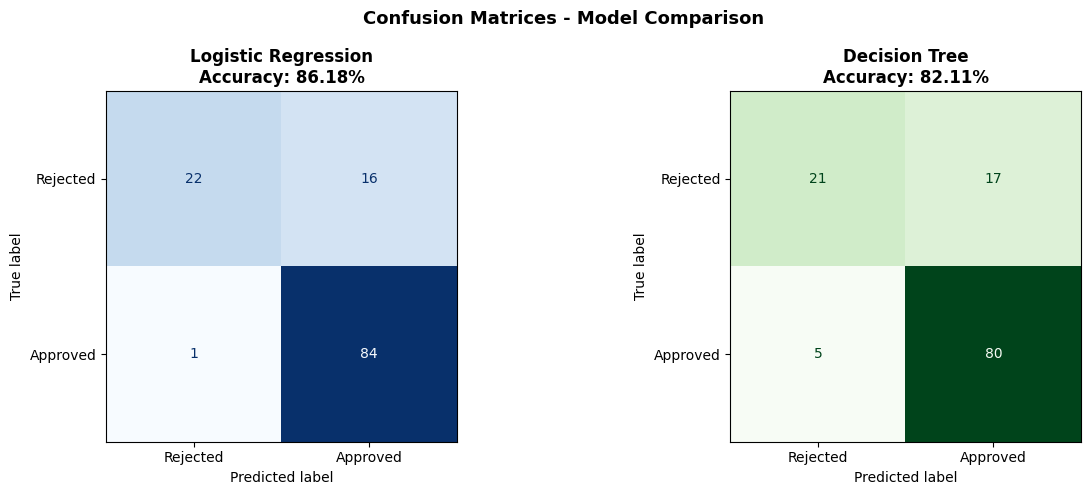


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

    Rejected       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

    Rejected       0.81      0.55      0.66        38
    Approved       0.82      0.94      0.88        85

    accuracy                           0.82       123
   macro avg       0.82      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123



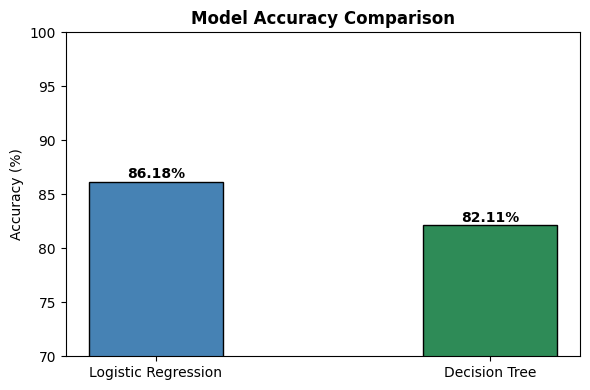

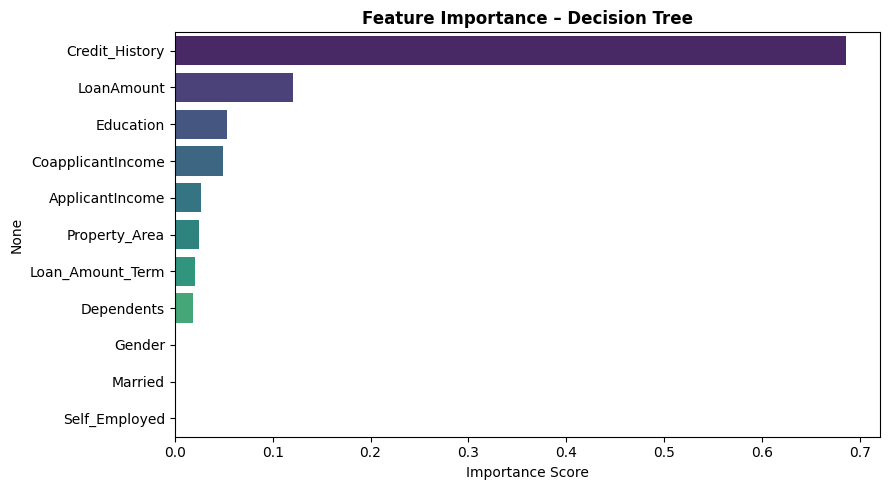


CONCLUSION

📌 Objective  : Predict loan default risk (binary classification)
📌 Dataset    : Loan Prediction Dataset (Kaggle)

🔹 Missing values were handled using mode (categorical)
   and median (numerical) imputation.

🔹 Key EDA Insights:
   - Applicants with good credit history are much more
     likely to get loans approved.
   - Graduates tend to get higher loan amounts approved.
   - Higher income does not always guarantee approval.

🔹 Model Performance:
   - Logistic Regression Accuracy : 86.18%
   - Decision Tree Accuracy        : 82.11%

🏆 Best Performing Model : Logistic Regression (86.18% accuracy)

🔹 Top Predictive Features (from Decision Tree):
   - Credit History, LoanAmount, ApplicantIncome



In [15]:
# ============================================================
# TASK 2: CREDIT RISK PREDICTION
# DevelopersHub Corporation - Data Science & Analytics Internship
# ============================================================

# ============================================================
# STEP 1: INSTALL & IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

# ============================================================
# STEP 2: LOAD DATASET (Manual Upload)
# ============================================================

from google.colab import files
print("Please upload the file: train_u6lujuX_CVtuZ9i.csv")
uploaded = files.upload()

df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
print("Dataset loaded successfully!")
print(df.shape)

# ============================================================
# STEP 3: DATASET UNDERSTANDING
# ============================================================

print("\n" + "="*55)
print("DATASET OVERVIEW")
print("="*55)
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

# ============================================================
# STEP 4: DATA CLEANING & HANDLING MISSING VALUES
# ============================================================

print("\n" + "="*55)
print("MISSING VALUES BEFORE CLEANING")
print("="*55)
print(df.isnull().sum())

# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Yellow = Missing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Fill missing values ---
# Categorical columns → fill with mode
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical columns → fill with median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

print("\nMISSING VALUES AFTER CLEANING:")
print(df.isnull().sum())
print("\n All missing values handled!")

# ============================================================
# STEP 5: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("\n" + "="*55)
print("EXPLORATORY DATA ANALYSIS")
print("="*55)

# ---- Plot 1: Loan Status Distribution ----
plt.figure(figsize=(6, 4))
colors = ['#e74c3c', '#2ecc71']
df['Loan_Status'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Loan Status Distribution (Y = Approved, N = Rejected)', fontweight='bold')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---- Plot 2: Loan Amount Distribution ----
plt.figure(figsize=(8, 4))
sns.histplot(df['LoanAmount'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Distribution of Loan Amount', fontweight='bold')
plt.xlabel('Loan Amount (in thousands)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ---- Plot 3: Education vs Loan Status ----
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set2')
plt.title('Education Level vs Loan Approval Status', fontweight='bold')
plt.xlabel('Education')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

# ---- Plot 4: Applicant Income Distribution ----
plt.figure(figsize=(8, 4))
sns.histplot(df['ApplicantIncome'], bins=40, kde=True, color='darkorange')
plt.title('Distribution of Applicant Income', fontweight='bold')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ---- Plot 5: Income vs Loan Amount (Scatter) ----
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount',
                hue='Loan_Status', palette='coolwarm', alpha=0.7)
plt.title('Applicant Income vs Loan Amount', fontweight='bold')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.tight_layout()
plt.show()

# ---- Plot 6: Box Plot - Loan Amount by Loan Status ----
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Loan_Status', y='LoanAmount', palette='Set3')
plt.title('Loan Amount by Loan Status', fontweight='bold')
plt.xlabel('Loan Status (N = Rejected, Y = Approved)')
plt.ylabel('Loan Amount')
plt.tight_layout()
plt.show()

# ---- Plot 7: Credit History vs Loan Status ----
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Credit_History', hue='Loan_Status', palette='muted')
plt.title('Credit History vs Loan Approval', fontweight='bold')
plt.xlabel('Credit History (1 = Good, 0 = Bad)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 6: FEATURE ENGINEERING & ENCODING
# ============================================================

print("\n" + "="*55)
print("ENCODING CATEGORICAL FEATURES")
print("="*55)

# Drop Loan_ID (not useful for prediction)
df.drop('Loan_ID', axis=1, inplace=True)

# Encode all object columns using Label Encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
    print(f"  Encoded: {col}")

print("\n Encoding complete!")
print(f"\nFinal Dataset Shape: {df.shape}")
print(df.head())

# ============================================================
# STEP 7: TRAIN / TEST SPLIT
# ============================================================

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

# ============================================================
# STEP 8: MODEL TRAINING
# ============================================================

print("\n" + "="*55)
print("MODEL TRAINING")
print("="*55)

# --- Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# --- Decision Tree ---
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print(f"\n Logistic Regression Accuracy : {lr_acc * 100:.2f}%")
print(f" Decision Tree Accuracy        : {dt_acc * 100:.2f}%")

# ============================================================
# STEP 9: MODEL EVALUATION
# ============================================================

print("\n" + "="*55)
print("MODEL EVALUATION")
print("="*55)

# ---- Confusion Matrix - Logistic Regression ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Rejected', 'Approved'])
disp_lr.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_acc*100:.2f}%', fontweight='bold')

cm_dt = confusion_matrix(y_test, dt_pred)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Rejected', 'Approved'])
disp_dt.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Decision Tree\nAccuracy: {dt_acc*100:.2f}%', fontweight='bold')

plt.suptitle('Confusion Matrices - Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ---- Classification Reports ----
print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, lr_pred, target_names=['Rejected', 'Approved']))

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, dt_pred, target_names=['Rejected', 'Approved']))

# ---- Model Accuracy Comparison Bar Chart ----
plt.figure(figsize=(6, 4))
models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_acc * 100, dt_acc * 100]
bars = plt.bar(models, accuracies, color=['steelblue', 'seagreen'], edgecolor='black', width=0.4)
plt.ylim(70, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison', fontweight='bold')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ---- Feature Importance (Decision Tree) ----
plt.figure(figsize=(9, 5))
feat_imp = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Feature Importance – Decision Tree', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ============================================================
# STEP 10: CONCLUSION
# ============================================================

best_model = "Logistic Regression" if lr_acc >= dt_acc else "Decision Tree"
best_acc = max(lr_acc, dt_acc) * 100

print("\n" + "="*55)
print("CONCLUSION")
print("="*55)
print(f"""
📌 Objective  : Predict loan default risk (binary classification)
📌 Dataset    : Loan Prediction Dataset (Kaggle)

🔹 Missing values were handled using mode (categorical)
   and median (numerical) imputation.

🔹 Key EDA Insights:
   - Applicants with good credit history are much more
     likely to get loans approved.
   - Graduates tend to get higher loan amounts approved.
   - Higher income does not always guarantee approval.

🔹 Model Performance:
   - Logistic Regression Accuracy : {lr_acc*100:.2f}%
   - Decision Tree Accuracy        : {dt_acc*100:.2f}%

🏆 Best Performing Model : {best_model} ({best_acc:.2f}% accuracy)

🔹 Top Predictive Features (from Decision Tree):
   - Credit History, LoanAmount, ApplicantIncome
""")